In [2]:
import numpy as np
from scipy.interpolate import *
from scipy.sparse.linalg import cg, LinearOperator
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from operator import *

In [3]:
def apply_stencil(u, diag = 1, should_print = True):
    #if should_print:
    #    print("The factor diag in apply stencil is: ", diag)
    i, j, k = u.shape
    result = np.zeros_like(u)
    result[1:-1, 1:-1, 1:-1] = (
        + 6*u[1:-1, 1:-1, 1:-1]
        - u[2:, 1:-1, 1:-1] - u[:-2, 1:-1, 1:-1]
        - u[1:-1, 2:, 1:-1] - u[1:-1, :-2, 1:-1]
        - u[1:-1, 1:-1, 2:] - u[1:-1, 1:-1, :-2]
        
    ) / diag
    return result


def compute_res(u, rhs, diag):
    #print("The factor diag in compute res is: ", diag)
    temp = apply_stencil(u, diag) - rhs
    return np.sqrt(np.sum(temp*temp)) / np.sqrt(np.sum(rhs*rhs))



def rb_gauss_seidel_3d(u, f, diag=1, iterations=3):
    #print("The factor diag in rb_gauss_seidel_3d is: ", diag)
    n, m, p = u.shape
    for _ in range(iterations):
        # Red update: (i + j + k) % 2 == 0
        for i in range(1, n - 1):
            for j in range(1, m - 1):
                for k in range(1, p - 1):
                    if (i + j + k) % 2 == 0:
                        u[i, j, k] = (1/6) * (
                            u[i+1, j, k] + u[i-1, j, k] +
                            u[i, j+1, k] + u[i, j-1, k] +
                            u[i, j, k+1] + u[i, j, k-1] +
                            diag * f[i, j, k]
                        )
        # Black update: (i + j + k) % 2 == 1
        for i in range(1, n - 1):
            for j in range(1, m - 1):
                for k in range(1, p - 1):
                    if (i + j + k) % 2 == 1:
                        u[i, j, k] =  (1/6) * (
                            u[i+1, j, k] + u[i-1, j, k] +
                            u[i, j+1, k] + u[i, j-1, k] +
                            u[i, j, k+1] + u[i, j, k-1] +
                            diag * f[i, j, k]
                        )
    return u


def restrict(res):
    return res[::2, ::2, ::2]



def prolong_with_rgi(u_coarse):
    nx, ny, nz = u_coarse.shape

    # 1. Define the coarse grid coordinates
    x_coarse = np.linspace(0, 1, nx)
    y_coarse = np.linspace(0, 1, ny)
    z_coarse = np.linspace(0, 1, nz)

    # 2. Set up the interpolator
    interpolator = RegularGridInterpolator(
        (x_coarse, y_coarse, z_coarse),
        u_coarse,
        method='linear',
        bounds_error=False,
        fill_value=0.0  # Can also be 'nearest' or extrapolation value
    )

    # 3. Define the fine grid coordinates (twice as fine)
    nx_f, ny_f, nz_f = 2 * nx - 1, 2 * ny - 1, 2 * nz - 1
    x_fine = np.linspace(0, 1, nx_f)
    y_fine = np.linspace(0, 1, ny_f)
    z_fine = np.linspace(0, 1, nz_f)

    # 4. Create meshgrid and points to evaluate
    X, Y, Z = np.meshgrid(x_fine, y_fine, z_fine, indexing='ij')
    points = np.stack((X, Y, Z), axis=-1)  # shape (nx_f, ny_f, nz_f, 3)

    # 5. Interpolate
    u_fine = interpolator(points)  # returns shape (nx_f, ny_f, nz_f)

    return u_fine

In [4]:
def set_boundary_conditions(u):
    i, j, k = np.shape(u)
    for x in range(i):
        for y in range(j):
            u[x, y, k-1]=1
            u[x, y, 0]= 0

    for x in range(i):
        for z in range(k):
            u[x, j-1, z] = z / (k-1)
            u[x, 0, z] = z / (k-1)

    for y in range(j):
        for z in range(k):
            u[i-1, y, z] = z / (k-1)
            u[0, y, z] = z / (k-1)



shape=(3,3,3)

# Matrix-vector product for flattened input
def matvec_shape(x_flat, shape, factor = 2):
    x_grid = np.zeros([shape[0]+2,shape[1]+2,shape[2]+2])
    x_grid[1:-1, 1:-1, 1:-1] = x_flat.reshape(shape)
    Ax_grid = apply_stencil(x_grid, should_print = False) / factor #We need to divide by 2 in order to get good convergence
    return Ax_grid[1:-1, 1:-1, 1:-1].ravel()

def get_matvec_shape(shape, factor=2):
    #print("The factor in get_matvec is: ", factor)
    return lambda x_flat: matvec_shape(x_flat, shape, factor)

In [22]:
def multigrid_V_cycle(base_length, num_iters=[1 , 1], num_smooth = 2, num_levels = None, level_num = None, rhs = None):

    if (num_levels==None or level_num==None):
        num_levels=level_num=len(num_iters)

    if(len(num_iters) == 1):
        num_iters = [num_iters[0] for i in range(num_levels)]
    
    length_by_level = [2**n*base_length + 1 for n in range(1, level_num + 1)]

    #Allocating working array
    guess = np.zeros(length_by_level[level_num-1])
    u = np.zeros(length_by_level[level_num-1])

    #if in uppermost level, set up the problem
    if rhs is None:        
        #setting boundary conditions       
        set_boundary_conditions(u)
        #print(u)
        #Allocating right hand side
        rhs = -apply_stencil(u)



    #getting matvec function and linear operator
    if level_num == 1:
        matvec = get_matvec_shape(length_by_level[0]-2, 2**(num_levels-level_num))
        n = (2*base_length[0]-1)*(2*base_length[1]-1)*(2*base_length[2]-1)
        A = LinearOperator((n, n), matvec=matvec)
        unravel_c = rhs[1:-1, 1:-1, 1:-1].ravel()
        #solving coarse_grid
        sol = cg(A, unravel_c)[0]
        #print (sol)
        sol_shaped = sol.reshape(2*base_length-1)
        rhs[1:-1, 1:-1, 1:-1] = sol_shaped
        
        return rhs




    #Now doing the multigrid operation
    residuals = []
    for i in range(num_iters[0]):
        if level_num==num_levels:
            residuum = compute_res(guess, rhs, 2**(num_levels-level_num))
            print("After ", i, " iterations the residual is ", residuum)
            residuals.append(residuum)

        #print("The current level is: ", level_num)
        #print("The rhs is: ")
        #print(rhs)
        #print("The guess before presmoothing is: ")
        #print(guess)
        rb_gauss_seidel_3d(guess, rhs, 2**(num_levels-level_num), iterations = num_smooth)
        #print("The guess after the rb_gauss_seidel is: ")
        #print(guess)
        #print("The right hand side for the ")
        #print("The guess after a ", 2, " Gauss-Seidel iteration is: ")
        #print(guess)
        #coarsening
        defect_domain = rhs-apply_stencil(guess, diag = 2**(num_levels-level_num))
        #print("The defect domain before coarsening is: ")
        #print(defect_domain)
        coarse = restrict(defect_domain)
        #print("After coarsening")
        #print(coarse)
        coarse = multigrid_V_cycle(base_length, num_iters[1 : ] ,num_smooth ,num_levels, level_num-1,rhs = coarse)
        #print("After coarse grid solve")
        #print(coarse)

        #refining
       
        refinemend = prolong_with_rgi(coarse)

        #print("The refined coarse grid solution: ")
        #print(refinemend)

        #Adding correction
        #print (refinemend.shape)
        guess[1:-1, 1:-1, 1:-1]+=refinemend[1:-1, 1:-1, 1:-1]

        #print("After adding the coarse grid correction the guess is:")
        #print(guess)
        
        #doing the post smoothing
        #print("Current level: ", level_num)
        rb_gauss_seidel_3d(guess, rhs, 2**(num_levels-level_num), iterations= num_smooth)

        #print("After the post smoothing step the guess is:")
        #print(guess)

    guess+=u


    return (guess, residuals) if level_num==num_levels else guess

In [24]:
np.set_printoptions(precision=3, suppress=True)
base_length = np.array([1,1,1])
#

#multigrid_V_cycle(base_length, [10, 1], num_levels = 3, level_num=2);
guess, residuals = multigrid_V_cycle(base_length, [10, 1]);

#xs= np.linspace(0, 9, 10)

#popt, pcov  = curve_fit(lambda b, a: pow(a, b), xs, residuals, p0 = [0.05])

#plt.xlabel("num iters")
#plt.ylabel("Residual")
#plt.title("Residual after n iterations")
#plt.yscale("log")
#plt.grid(True, which="both", linestyle='--')
#plt.plot(xs, residuals)
#plt.savefig("Residual_plot.pdf",format="pdf")

#print("The computed convergence rate is: ", popt[0])

After  0  iterations the residual is  1.0
After  1  iterations the residual is  0.01173030995331497
After  2  iterations the residual is  9.088229127569826e-05
After  3  iterations the residual is  7.209254078422026e-07
After  4  iterations the residual is  5.731159558338171e-09
After  5  iterations the residual is  4.557051458046726e-11
After  6  iterations the residual is  3.6238052141999837e-13
After  7  iterations the residual is  2.887937936489145e-15
After  8  iterations the residual is  1.4556633306063214e-16
After  9  iterations the residual is  0.0


After  0  iterations the residual is  1.0
After  1  iterations the residual is  0.05745543684879223
After  2  iterations the residual is  0.0019321056534516439
After  3  iterations the residual is  6.630135890493825e-05
After  4  iterations the residual is  2.3504720335764625e-06
After  5  iterations the residual is  8.531230605982272e-08
After  6  iterations the residual is  3.1169548983853765e-09
After  7  iterations the residual is  1.1944857130071445e-10
After  8  iterations the residual is  4.5638253419774165e-12
After  9  iterations the residual is  1.96576577101838e-13
The computed convergence rate is:  0.057299394586725526


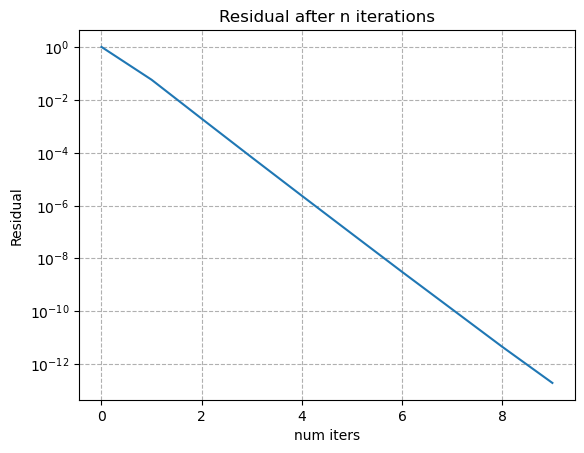

In [10]:
np.set_printoptions(precision=3)
base_length = np.array([16,16,16])
guess, residuals = multigrid_V_cycle(base_length, [10, 1, 1], 2)

xs= np.linspace(0, 9, 10)

popt, pcov  = curve_fit(lambda b, a: pow(a, b), xs, residuals, p0 = [0.05])
print("The computed convergence rate is: ", popt[0])

plt.xlabel("num iters")
plt.ylabel("Residual")
plt.title("Residual after n iterations")
plt.yscale("log")
plt.grid(True, which="both", linestyle='--')
plt.plot(xs, residuals)
plt.savefig("Residual_plot_3_l.pdf",format="pdf")


After  0  iterations the residual is  1.0
After  1  iterations the residual is  0.05907637512173832
After  2  iterations the residual is  0.002018015513223702
After  3  iterations the residual is  7.00667073744844e-05
After  4  iterations the residual is  2.4977520055473975e-06
After  5  iterations the residual is  9.247096491947256e-08
After  6  iterations the residual is  3.430882178284332e-09
After  7  iterations the residual is  1.4048996302879212e-10
After  8  iterations the residual is  5.954139279449442e-12
After  9  iterations the residual is  3.069888704790443e-13
The computed convergence rate is:  0.05890395249388863


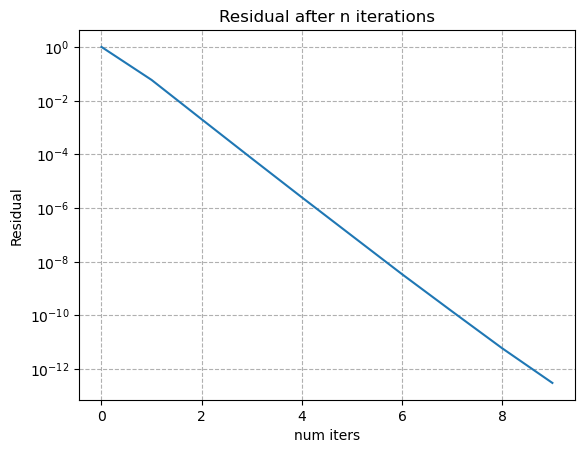

In [8]:
np.set_printoptions(precision=3)
base_length = np.array([16,16,16])
guess, residuals = multigrid_V_cycle(base_length, [10, 1, 1, 1], 2)

popt, pcov  = curve_fit(lambda b, a: pow(a, b), xs, residuals, p0 = [0.05])
print("The computed convergence rate is: ", popt[0])

xs= np.linspace(0, 9, 10)
plt.xlabel("num iters")
plt.ylabel("Residual")
plt.title("Residual after n iterations")
plt.yscale("log")
plt.grid(True, which="both", linestyle='--')
plt.plot(xs, residuals)
plt.savefig("Residual_plot_4_l.pdf",format="pdf")

After  0  iterations the residual is  1.0
After  1  iterations the residual is  0.05973549383239717
After  2  iterations the residual is  0.002053590833551639
After  3  iterations the residual is  7.163604488981955e-05
After  4  iterations the residual is  2.562772747099941e-06
After  5  iterations the residual is  9.520613200087876e-08
After  6  iterations the residual is  3.5353486710328263e-09
After  7  iterations the residual is  1.4443515349820794e-10
After  8  iterations the residual is  6.004860230338881e-12
After  9  iterations the residual is  2.9945029521551733e-13
The computed convergence rate is:  0.059556124927733226


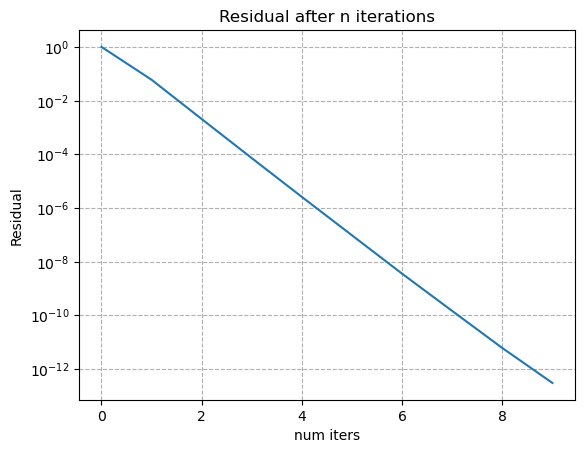

In [9]:
num_iters = 10

np.set_printoptions(precision=3)
base_length = np.array([16, 16, 16])
guess, residuals = multigrid_V_cycle(base_length, [num_iters, 1, 1, 1, 1], 2)

xs= np.linspace(0, num_iters-1, num_iters)

popt, pcov  = curve_fit(lambda b, a: pow(a, b), xs, residuals, p0 = [0.05])
print("The computed convergence rate is: ", popt[0])

plt.xlabel("num iters")
plt.ylabel("Residual")
plt.title("Residual after n iterations")
plt.yscale("log")
plt.grid(True, which="both", linestyle='--')
plt.plot(xs, residuals)
plt.savefig("Residual_plot_5_l.pdf",format="pdf")

After  0  iterations the residual is  1.0
After  1  iterations the residual is  0.05585115644076103
After  2  iterations the residual is  0.0018522438447117816
After  3  iterations the residual is  6.30944144408938e-05
After  4  iterations the residual is  2.212444316301323e-06
After  5  iterations the residual is  8.058626125522625e-08
After  6  iterations the residual is  2.93675680419874e-09
After  7  iterations the residual is  1.161137544648745e-10
After  8  iterations the residual is  4.632151445652618e-12
After  9  iterations the residual is  2.1799375976680503e-13
The computed convergence rate is:  0.055710692033702734


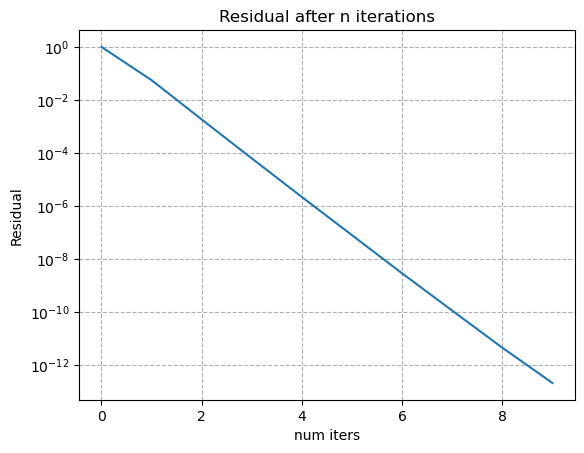

In [168]:
num_iters = 10

np.set_printoptions(precision=3)
base_length = np.array([1,1,1])
guess, residuals = multigrid_V_cycle(base_length, [num_iters, 1, 1, 1, 1, 1])

popt, pcov  = curve_fit(lambda b, a: pow(a, b), xs, residuals, p0 = [0.05])
print("The computed convergence rate is: ", popt[0])

xs= np.linspace(0, num_iters-1, num_iters)
plt.xlabel("num iters")
plt.ylabel("Residual")
plt.title("Residual after n iterations")
plt.yscale("log")
plt.grid(True, which="both", linestyle='--')
plt.plot(xs, residuals)
plt.savefig("Residual_plot_6_l.pdf",format="pdf")